# Data Visualization Basics
This project will answer some, meaby obvious, questions that are in the seaborn 'tips' dataset. I am going to compare seaborn and matplotlib vizualization tools to compare them and see wether there is a diffrence, but first let's see the questions:

1. What is the distribution of total bills? Are there any unusually high or low values (outliers)?
2. Is there a relationship between the total bill amount and the tip amount?
3. Does gender influence tip amounts? Who leaves higher tips – males or females?
4. Which day of the week has the most customers? On which days are tips the highest?
5. Does the time of day (lunch vs dinner) affect total bill and tip amounts?
6. Does the size of the group (number of people at the table) affect the total bill and tip?
7. Which variables are most strongly correlated with each other? Are there hidden relationships?
8. Are there specific days where tips are exceptionally high or low compared to other days?

Now we can import everything, anylize what data I have and start answering some questions.

In [442]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

tips = sns.load_dataset('tips')

tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


tips data set contains 7 columns:

1. total_bill - how much was costing the dinner or lunch, in dollars
2. tip - how much was tipped, also in dollars
3. sex - gender of a customer
4. smoker - wether the person was smoking or not
5. day - on which day in the week was it
6. time - whether it was a dinner or lunch
7. size - how many plates were ordered

## 1. What is the distribution of total bills? Are there any unusually high or low values (outliers)?

First I need to visualize distribution of total bills and see wether there are some outliers. I am going to use histogram to see the distribution and boxplot to see the outliers

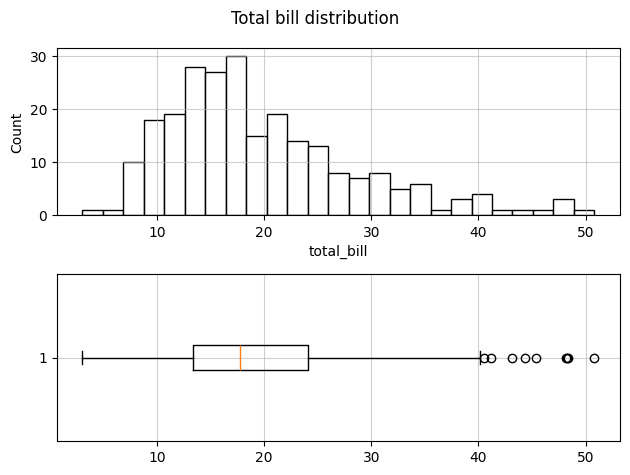

In [443]:
total_bill = tips['total_bill']

plt.subplot(2,1,1)
sns.histplot(total_bill, bins=25, edgecolor='black', color='w')
plt.grid(True,alpha=0.6)

plt.subplot(2,1,2)
plt.boxplot(total_bill, orientation='horizontal')
plt.grid(True,alpha=0.6)

plt.suptitle('Total bill distribution')
plt.tight_layout()


First let's look at the histogram, it is right-skewed / positively skewed, so it is longer on the right side, and we can see the same thing in the boxplot, we have outliers on the right side. It could be interpreted as people usually spent the same amount in the restaurant but sometimes there is an occasion, hence they spend more. On the other hand, it would be uncommon to see outliers on the left side as it we cannot go lower than 0.

## 2. Is there a relationship between the total bill amount and the tip amount?

I am going to use scatter plot here, it is great for two variables.

Text(0, 0.5, 'tip')

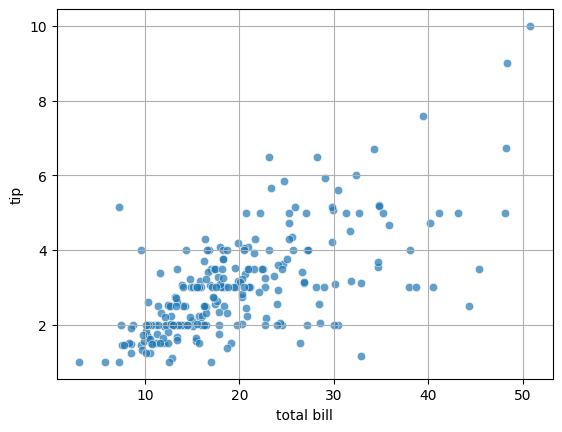

In [444]:
tip = tips['tip']

sns.scatterplot(x=total_bill,y=tip,alpha=0.7)
plt.grid(True)
plt.xlabel('total bill')
plt.ylabel('tip')

I can see two main things just by looking at it:
1. There is positive relationship between total bill and amount of tip, if the bill is higher usually the tip is bigger, there are some outliers but the line is clearly visable
2. People tend to round the tip, in the $2,$3,$4 we can see that there are more tips. It is normal behaviour as people usually don't calculate the excact amount, they just want to tip a small portion of their total bill.

## 3. Does gender influence tip amounts? Who leaves higher tips – males or females?

For this one bar chart will be a good choice, that way we can compare mean of tip amount by gender


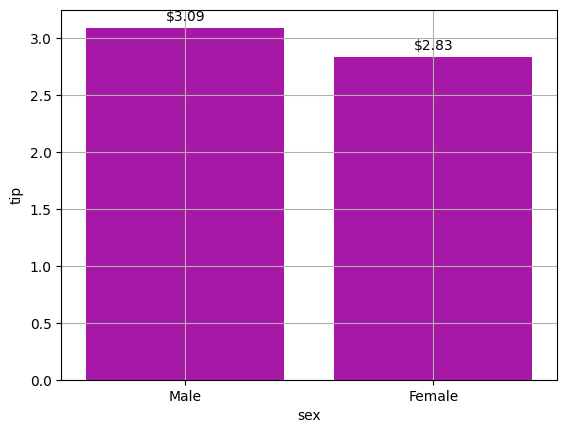

In [445]:
ax = sns.barplot(tip.groupby(tips['sex']).mean(),color='m')
plt.grid(True)

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3, fontsize=10)

I see only a little diffrence in the amount of average tip, I think it is too low too say there is an influence by gender

## 4. Which day of the week has the most customers? On which days are tips the highest?

In this point in also going to use bar plot

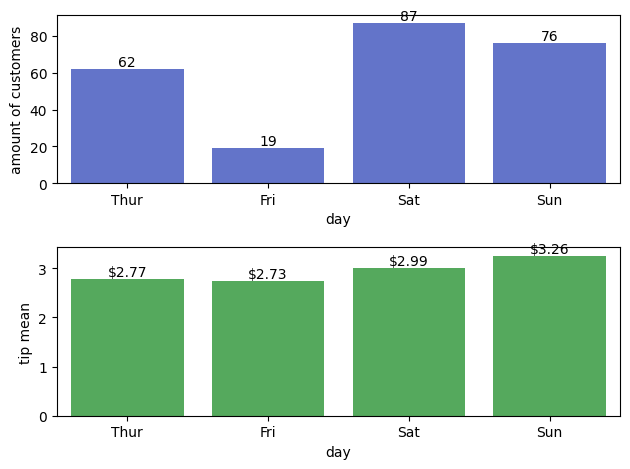

In [446]:
plt.subplot(2,1,1)
ax = sns.barplot(tips['day'].groupby(tips['day']).count(), alpha=0.9, color="#3f58d6",)
plt.ylabel('amount of customers')

plt.subplot(2,1,2)
ax2 = sns.barplot(tips['tip'].groupby(tips['day']).mean(),color="#47B752")
plt.ylabel('tip mean')

for container in ax.containers:
    ax.bar_label(container)
for container in ax2.containers:
    ax2.bar_label(container,fmt="$%.2f")

plt.tight_layout()

Saturday has the most customers with 87 people, while friday only has 19. This could mean that people tend to plan going out to restaurants on the weekends, that would explain why there is so little visits on friday. On Sunday tips are the highest, with 0.27 cents in diffrence to the second place which is Saturday.

## 5. Does the time of day (lunch vs dinner) affect total bill and tip amounts?

We can compare two box plots next to eachother to see the diffrence

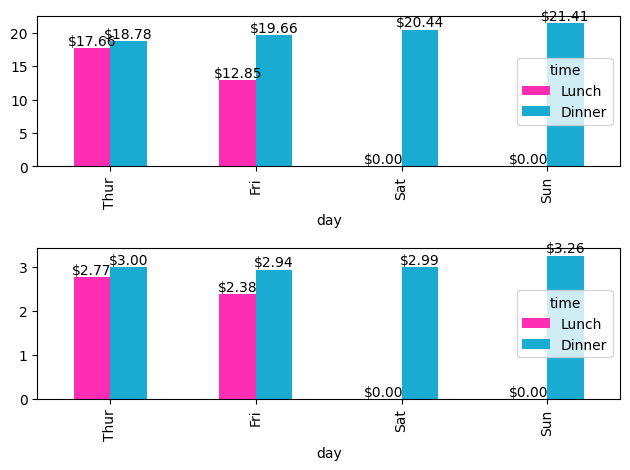

In [447]:
grouped = tips.groupby(['day', 'time'])[['total_bill','tip']].mean()

bill_mean = grouped['total_bill'].unstack()
tip_mean = grouped['tip'].unstack()

fig, axes = plt.subplots(2,1)

ax = bill_mean.plot(kind='bar', ax=axes[0], color=["#FF2DB2","#1AABD3"])
ax2 = tip_mean.plot(kind='bar', ax =axes[1], color=["#FF2DB2","#1AABD3"])

for axes in [ax, ax2]:
    for container in axes.containers:
        axes.bar_label(container, fmt='$%.2f')

plt.tight_layout()


I don't have a lot of data as Saturday and Sunday didn't have anybody at lunch time, but there is a clear diffrence in total bill and tip between lunch and dinner. I can say that time affects total bill and tip

## 6. Does the size of the group (number of people at the table) affect the total bill and tip?

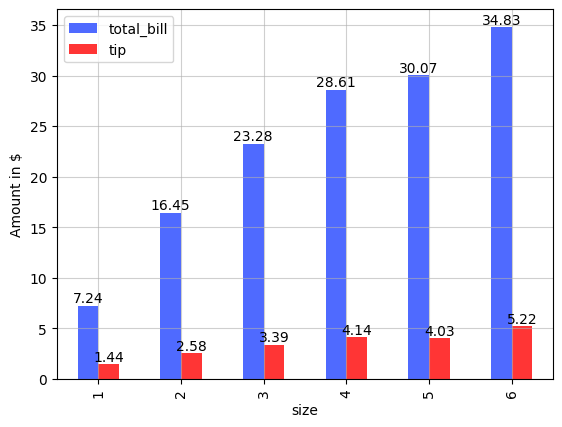

In [448]:
size_mean = tips.groupby('size')[['total_bill','tip']].mean()

ax = size_mean.plot(kind='bar',color=["#4F6AFFFF","#FF3535"])
plt.ylabel('Amount in $')

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.grid(True, alpha=0.6)


I can clearly see that if the size is bigger the total bill and tip go up. This is reasonable logic, people tend to leave the same percantage of the tip, so if the bill is bigger the tip will also be bigger.

## 7. Which variables are most strongly correlated with each other? Are there hidden relationships?

I know that there will be corelation between total bill and tip, size and total bill, size and tip, but there could be some hidden corelation I don't know about yet. First I need to transform categorical columns using one-hot method.

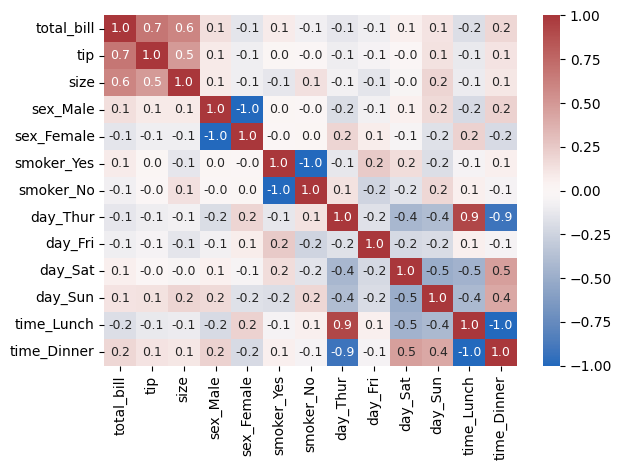

In [449]:
cat_col = ['sex','smoker','day','time']

dummies = pd.get_dummies(tips[cat_col])

corr_columns = tips.drop(cat_col,axis=1)
corr_columns = corr_columns.join(dummies)
corelations = corr_columns.corr()

sns.heatmap(corelations, cmap='vlag', annot=True,fmt='.1f', annot_kws={'size':9})
plt.tight_layout()

plt.savefig('corr_map.png', dpi=300) #dpi is the quality, 100 is set value, but 300 is good for printing

I can see that I was right with total_bill, tip and size. What is suprising is Thursday vs lunch. It looks like on that day there are far more lunches than dinners.

## 8. Are there specific days where tips are exceptionally high or low compared to other days?



<Axes: xlabel='day', ylabel='tip'>

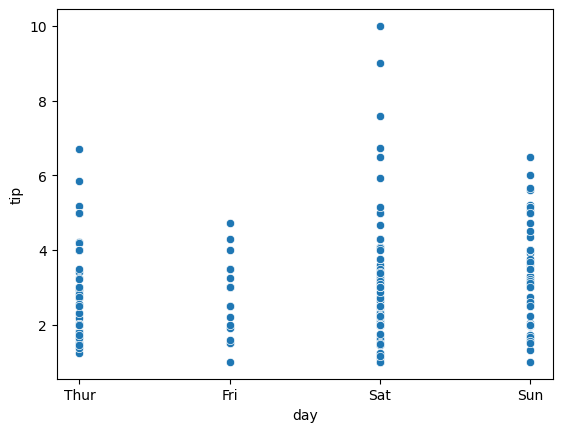

In [450]:
days = tips['day']

sns.scatterplot(x=days,y=tip)

I can see that Saturday has higher tips, but they are just outliers, we need to compare mean and median to connclude wether Saturday really has higher tips

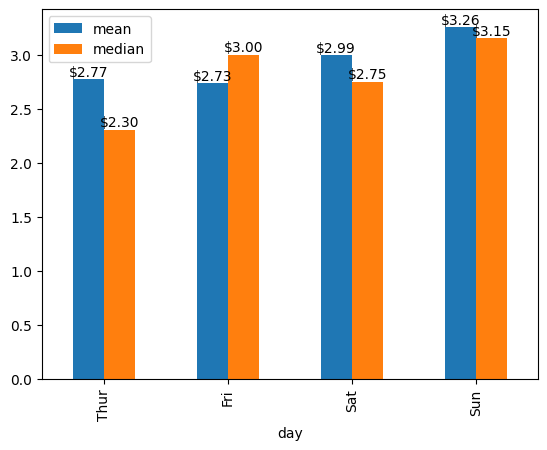

In [451]:
tip_median_mean = tips.groupby('day')['tip'].agg(['mean','median'])

ax = tip_median_mean.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f')

I can see something different now. On Sunday, mean and median are relatively close to each other, that mean there are normally higher tips on that day. On the other hand, looking at Thursday gives us something different we can see that mean is far higher than mean so there are lots of outliers which boost the mean. Saturday also has outliers that boost it mean. Friday has it other way around, it has outliers that lower the mean.


## 9. Summary

Now I can give a quick version of the answers that were written earlier:

1. What is the distribution of total bills? Are there any unusually high or low values (outliers)?
It is right skeewed, there are some unsually high values.

2. Is there a relationship between the total bill amount and the tip amount?
Yes, if the bill is higher, statistically the tip will be also higher

3. Does gender influence tip amounts? Who leaves higher tips – males or females?
No, there is little to do diffrence in the mean of the tip.

4. Which day of the week has the most customers? On which days are tips the highest?
Saturday, has the most customers, Sunday has the biggest tips.

5. Does the time of day (lunch vs dinner) affect total bill and tip amounts?
Yes, on dinner the mean is higher on Thursday and Friday, Satuday and Sunday, don't have lunches registered.

6. Does the size of the group (number of people at the table) affect the total bill and tip?
Yes, the bigger the size, the bigger the bill and the tip.

7. Which variables are most strongly correlated with each other? Are there hidden relationships?
There is a high correlation between lunch and Thursday.

8. Are there specific days where tips are exceptionally high or low compared to other days?
Sunday has statistically higher tips than anyother day.